# Flood Baseline Notebook 

## Imports

In [1]:
import os
import logging
import json
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve

## Config

In [2]:
PREPARED_DIR = Path(r"D:/Projects/datasets/raw/prepared")
SAMPLE_FILE_PREFIX = "selected_"

## Load Data

In [3]:
def get_dataset_files(prepared_dir: Path, prefix: str = "selected_") -> list[dict]:
    """Scans the directory and returns a list of dictionaries containing metadata and paths."""
    samples = []
    npz_files = sorted(prepared_dir.glob(f"{prefix}*.npz"))
    for npz_path in npz_files:
        meta_path = npz_path.with_suffix(".json")
        with open(meta_path, "r", encoding="utf-8") as f:
            meta = json.load(f)
        meta["npz_path"] = npz_path
        samples.append(meta)
    return samples

In [4]:
def split_train_val_test(samples: list[dict], val_frac: float = 0.2, test_frac: float = 0.2):
    """Splits samples chronologically per region."""
    # Group by region
    by_region = {}
    for s in samples:
        by_region.setdefault(s.get("region", "unknown"), []).append(s)

    train, val, test = [], [], []
    
    for region, region_samples in by_region.items():
        # Sort each region's samples by date
        region_samples.sort(key=lambda x: x["date"])
        n_total = len(region_samples)
        
        # Calculate split indices
        n_test = max(1, int(n_total * test_frac))
        n_val = max(1, int(n_total * val_frac)) 
        n_train = n_total - n_val - n_test
        
        train.extend(region_samples[:n_train])
        val.extend(region_samples[n_train:n_train + n_val])
        test.extend(region_samples[n_train + n_val:])

    return train, val, test

In [5]:
def load_target_masks(npz_path: Path, target: str = "s1_label") -> tuple[np.ndarray, np.ndarray]:
    """Loads the ground truth label and valid pixel mask for a specific target."""
    
    data = dict(np.load(npz_path, allow_pickle=False))
    
    if target == "s1_label":
        label = data["s1_label"]
        valid = data.get("s1_label_valid", np.isfinite(label))
    elif target == "gfm_mask":
        label = data["gfm_mask"]
        valid = data.get("gfm_valid", np.isfinite(label))
    else:
        # create an empty array of shape - (1, 2522, 6274)
        c, w, h = data["s1"].shape
        label = np.zeros((1, w, h), dtype=bool)
        valid = np.zeros((1, w, h), dtype=bool)
        
    label = label[0]
    valid = valid[0]

    return label.astype(bool), valid.astype(bool)

### Run

In [6]:
samples = get_dataset_files(PREPARED_DIR, SAMPLE_FILE_PREFIX)
train_samples, val_samples, test_samples = split_train_val_test(samples)

#### Test

In [7]:
print(f"Train samples: {len(train_samples)}")
print(f"Val samples: {len(val_samples)}")
print(f"Test samples: {len(test_samples)}")
print(f"Columns: {train_samples[0].keys()}")

Train samples: 12
Val samples: 4
Test samples: 4
Columns: dict_keys(['sample_id', 'region', 'date', 'shape_by_key', 'pos_weight', 'positive_ratio', 'crs', 'transform', 'npz_path'])


In [8]:
label, valid = load_target_masks(samples[0]["npz_path"], target="gfm_mask")

In [9]:
sample_metadata = train_samples[0]
npz_path = sample_metadata["npz_path"]

print("--- Sample Metadata ---")
for key, value in sample_metadata.items():
    print(f"{key}: {value}")

print("\n--- Inspecting Raw Arrays ---")
with np.load(npz_path, allow_pickle=False) as data:
    print(f"Available keys in archive: {data.files}")
    s1_array = data["s1"][:]
    print(f"S1 Array Shape (Channels, Height, Width): {s1_array.shape}")
    print(f"S1 Array Data Type: {s1_array.dtype}")

--- Sample Metadata ---
sample_id: selected_Gatineau_2019-04-01
region: Gatineau
date: 2019-04-01
shape_by_key: {'s1': [2, 2522, 6274], 's1_label': [1, 2522, 6274], 'env': [15, 2522, 6274], 'hydro': [1, 2522, 6274], 'weather': [6, 2522, 6274], 'glofas': [1, 2522, 6274], 'gfm_mask': [1, 2522, 6274], 's1_label_valid': [1, 2522, 6274], 'gfm_valid': [1, 2522, 6274]}
pos_weight: 1.0
positive_ratio: 0.0
crs: EPSG:4326
transform: [8.983152841195215e-05, 0.0, -75.90880931796892, 0.0, -8.983152841195215e-05, 45.59920247413421, 0.0, 0.0, 1.0]
npz_path: D:\Projects\datasets\raw\prepared\selected_Gatineau_2019-04-01.npz

--- Inspecting Raw Arrays ---
Available keys in archive: ['s1', 's1_label', 'env', 'hydro', 'weather', 'glofas', 'gfm_mask', 's1_label_valid', 'gfm_valid']
S1 Array Shape (Channels, Height, Width): (2, 2522, 6274)
S1 Array Data Type: float32


## Analyze

### Visualize Sample

In [10]:
def plot_sample(sample: dict,  plot_env_weather: bool = True):
    """Plots Sentinel-1 bands, S1 labels, GFM ground truth, env, and weather for a given sample."""
    npz_path = sample["npz_path"]

    with np.load(npz_path, allow_pickle=False) as data:
        s1 = data["s1"][:]
        if plot_env_weather:
            env = data["env"][:]
            weather = data["weather"][:]
        
    vv = s1[0]
    vh = s1[1] if s1.shape[0] > 1 else s1[0]

    
    if plot_env_weather:
        fig, axes = plt.subplots(5, 5, figsize=(20, 20))
    else:
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        
    axes = axes.flatten()

    axes[0].imshow(vv, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("S1 VV (Normalized)")

    axes[1].imshow(vh, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("S1 VH (Normalized)")

    s1_label, _ = load_target_masks(npz_path, target="s1_label")
    axes[2].imshow(s1_label, cmap="Blues", interpolation="none")
    axes[2].set_title("S1 Label")

    gfm_label, _ = load_target_masks(npz_path, target="gfm_mask")
    axes[3].imshow(gfm_label, cmap="Reds", interpolation="none")
    axes[3].set_title("GFM Ground Truth")

    # --- Plot Env Data (Indices 4 to 18) ---
    if plot_env_weather:
        for i in range(15):
            axes[4 + i].imshow(env[i], cmap="viridis", vmin=0, vmax=1)
            axes[4 + i].set_title(f"Env Band {i}")
        for i in range(6):
            axes[19 + i].imshow(weather[i], cmap="magma")
            axes[19 + i].set_title(f"Weather Band {i}")

    # Clean up axes
    for ax in axes:
        ax.axis("off")

    plt.suptitle(f"Sample: {sample.get('sample_id')} | {sample.get('date')}", y=0.98, fontsize=16)
    plt.tight_layout()
    plt.show()

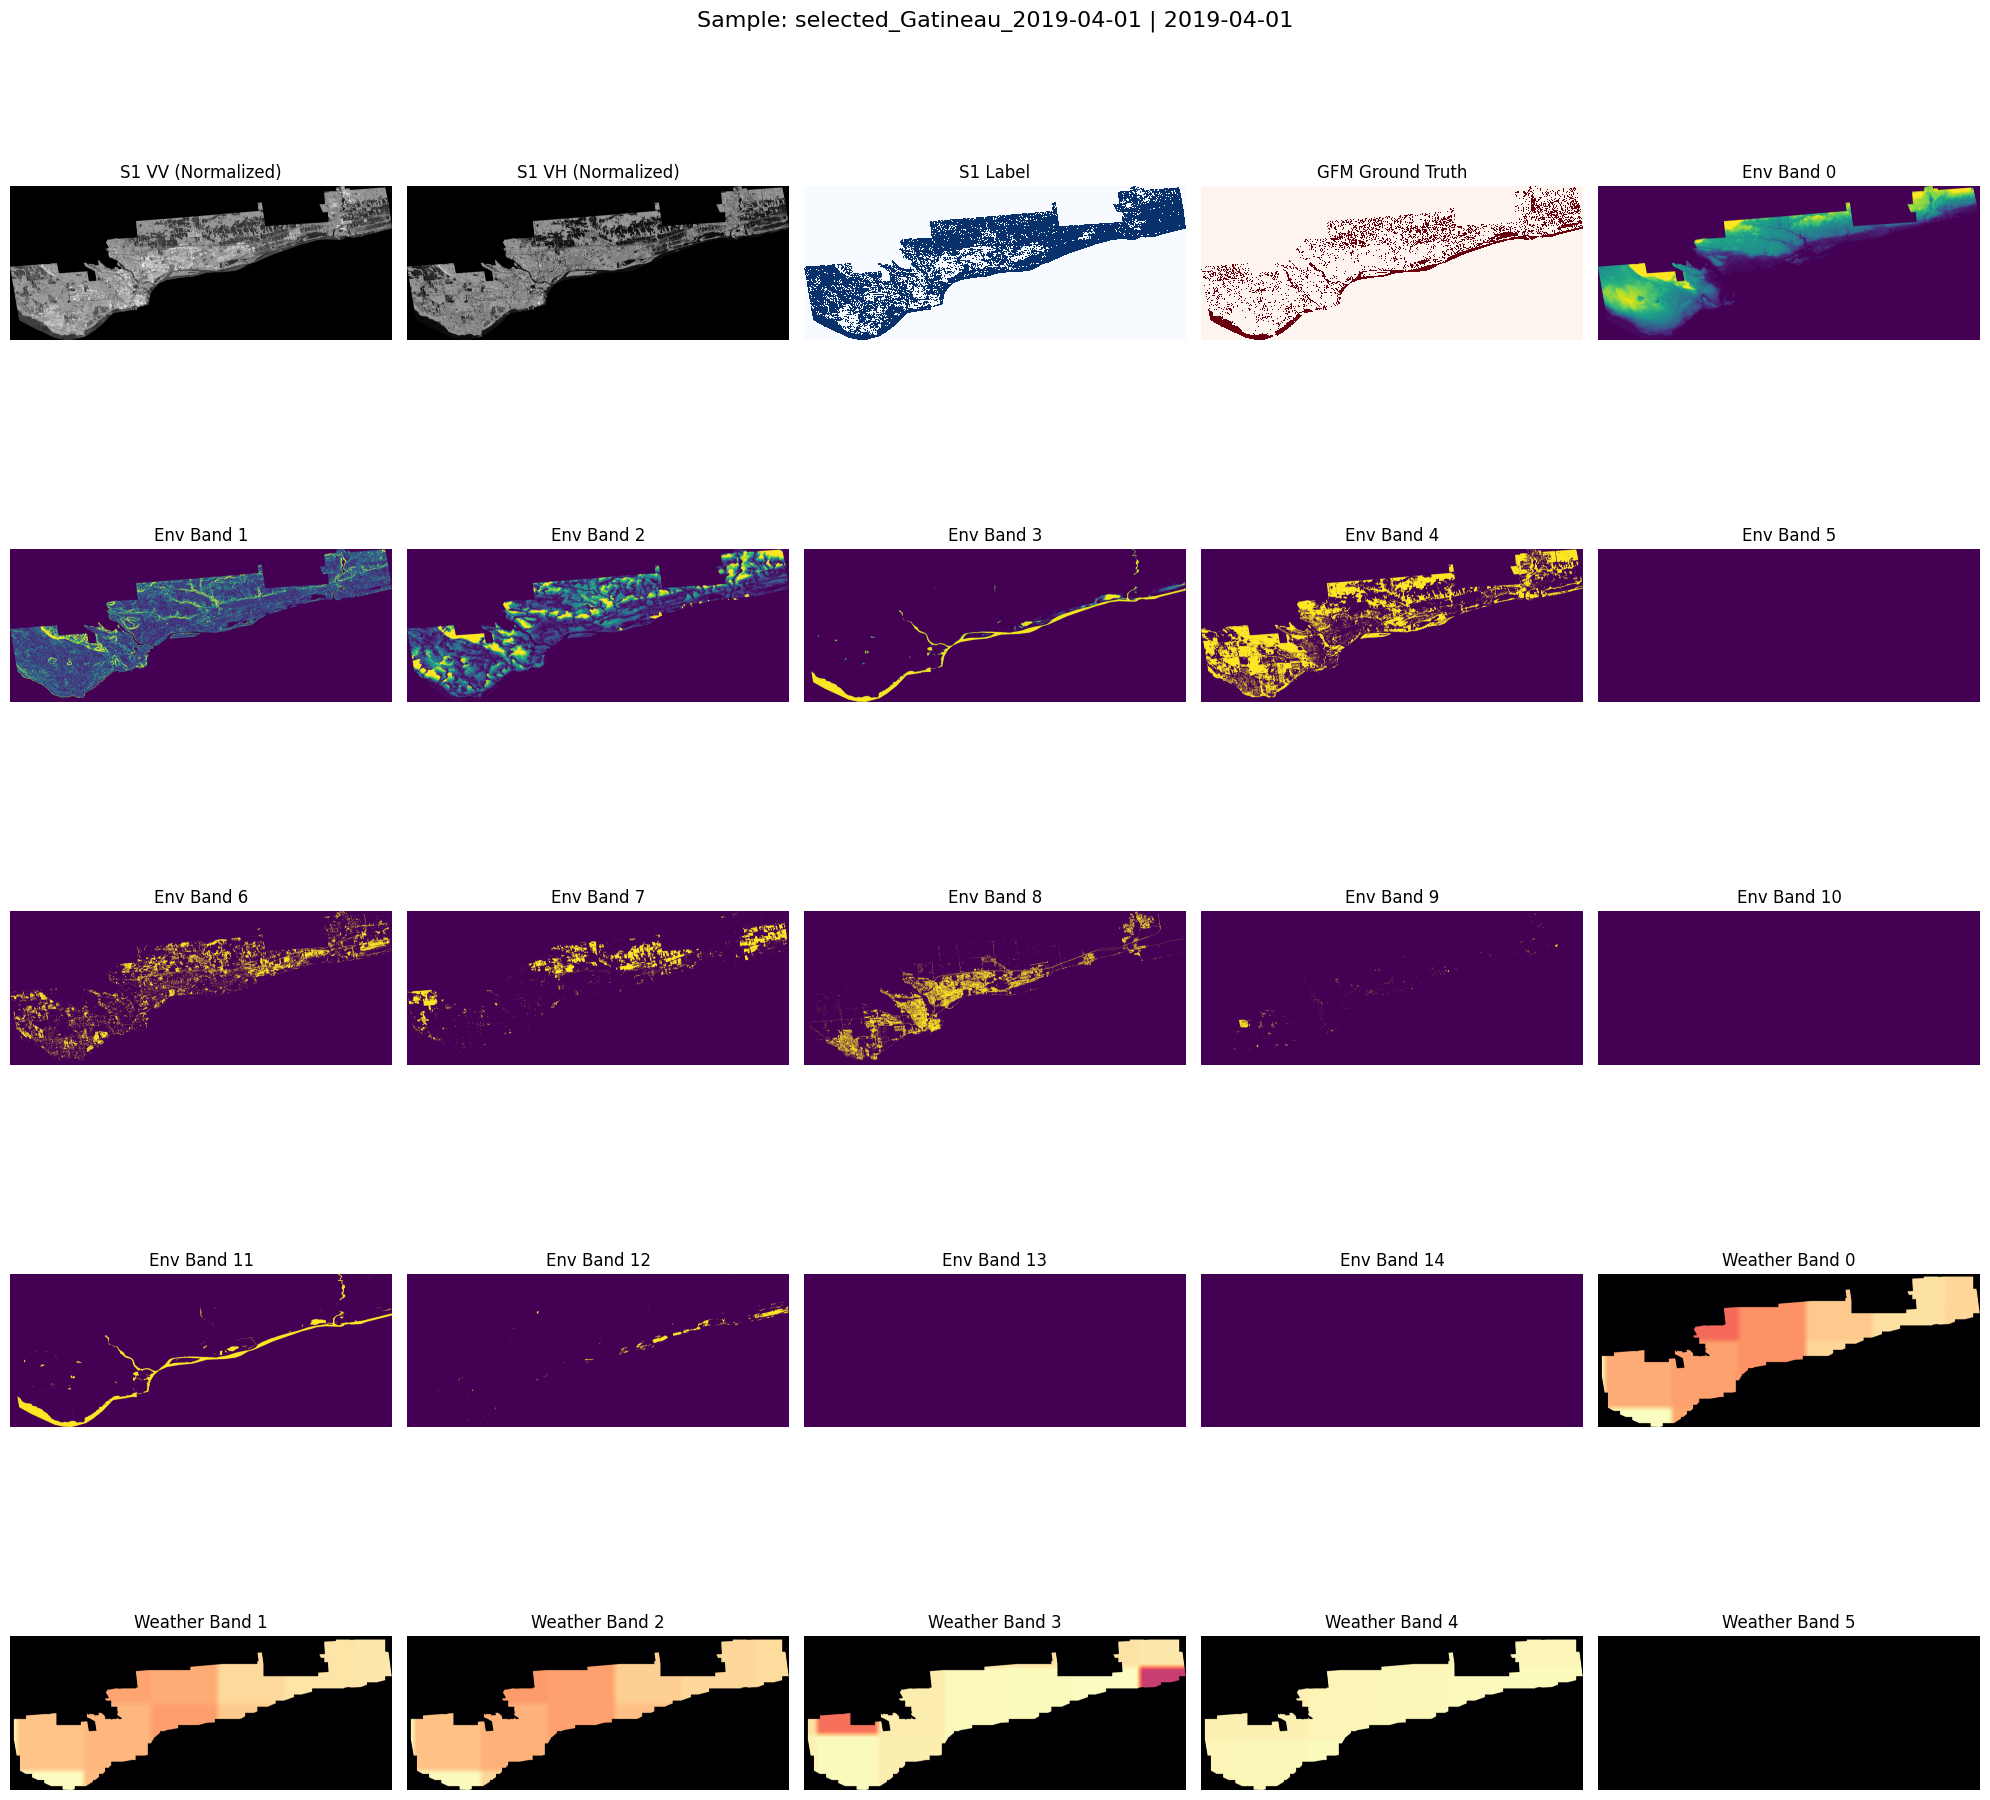

In [11]:
plot_sample(train_samples[0], plot_env_weather=True)

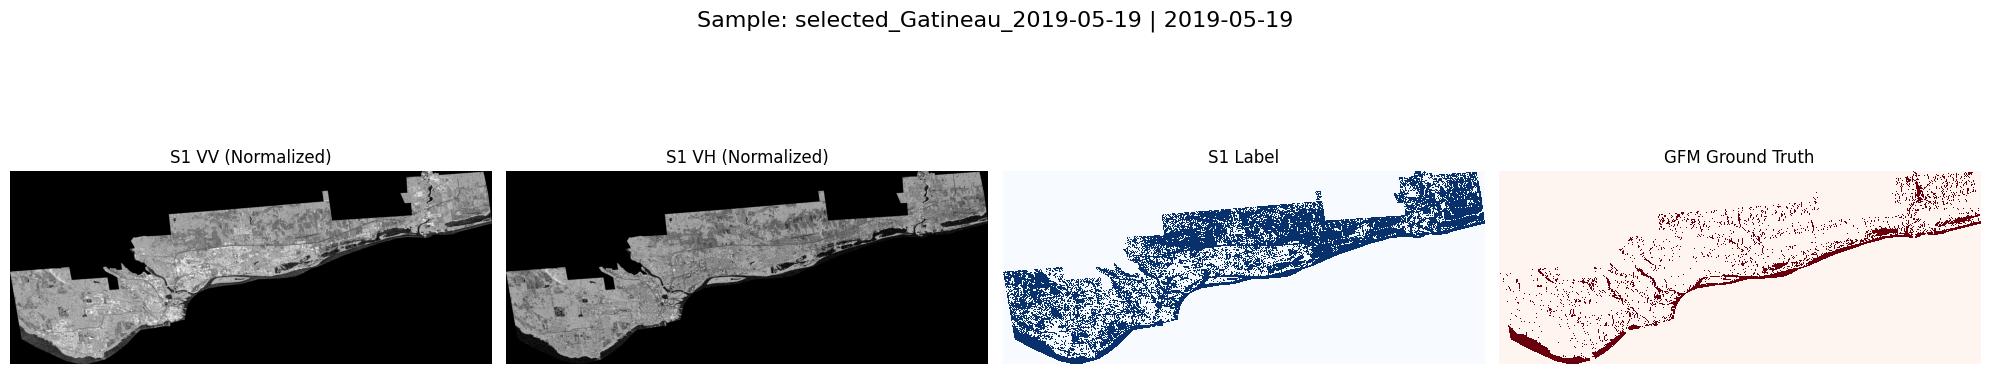

In [12]:
plot_sample(test_samples[0], plot_env_weather=False)

### Analyze labels

In [13]:
def analyze_dataset_and_features(samples: list[dict], split_name: str, max_intensity_files: int = 20, max_points: int = 50000) -> pd.DataFrame:
    fraction_results = []
    pos_vv_s1, pos_vh_s1, neg_vv_s1, neg_vh_s1 = [], [], [], []
    pos_vv_gfm, pos_vh_gfm, neg_vv_gfm, neg_vh_gfm = [], [], [], []

    for i, sample in enumerate(samples):
        npz_path = sample["npz_path"]
        
        with np.load(npz_path, allow_pickle=False) as data:
            s1 = data["s1"][:]
            
            # Calculate Fractions (Executes for all samples)
            s1_label, s1_valid = load_target_masks(npz_path, target="s1_label")
            s1_valid_count = s1_valid.sum()
            s1_frac = s1_label[s1_valid].mean() if s1_valid_count > 0 else np.nan

            gfm_label, gfm_valid = load_target_masks(npz_path, target="gfm_mask")
            gfm_valid_count = gfm_valid.sum()
            gfm_frac = gfm_label[gfm_valid].mean() if gfm_valid_count > 0 else np.nan

            fraction_results.append({
                "sample_id": sample.get("sample_id"),
                "s1_flood_fraction": s1_frac,
                "gfm_flood_fraction": gfm_frac
            })

            # Extract Intensities 
            if i < max_intensity_files:
                vv = s1[0]
                vh = s1[1] if s1.shape[0] > 1 else s1[0]
                
                is_flood_s1 = s1_valid & s1_label
                not_flood_s1 = s1_valid & (~s1_label)

                is_flood_gfm = gfm_valid & gfm_label
                not_flood_gfm = gfm_valid & (~gfm_label)

                pos_vv_s1.append(vv[is_flood_s1])
                pos_vh_s1.append(vh[is_flood_s1])
                neg_vv_s1.append(vv[not_flood_s1])
                neg_vh_s1.append(vh[not_flood_s1])

                pos_vv_gfm.append(vv[is_flood_gfm])
                pos_vh_gfm.append(vh[is_flood_gfm])
                neg_vv_gfm.append(vv[not_flood_gfm])
                neg_vh_gfm.append(vh[not_flood_gfm])

    # --- Aggregation and Plotting ---
    df_fractions = pd.DataFrame(fraction_results)

    # Concatenate S1 lists to numpy arrays
    pos_vv_s1, pos_vh_s1 = np.concatenate(pos_vv_s1), np.concatenate(pos_vh_s1)
    neg_vv_s1, neg_vh_s1 = np.concatenate(neg_vv_s1), np.concatenate(neg_vh_s1)
    
    # Concatenate GFM lists to numpy arrays
    pos_vv_gfm, pos_vh_gfm = np.concatenate(pos_vv_gfm), np.concatenate(pos_vh_gfm)
    neg_vv_gfm, neg_vh_gfm = np.concatenate(neg_vv_gfm), np.concatenate(neg_vh_gfm)
    
    # Subsample intensities to prevent plotting bottleneck
    idx_pos = np.random.choice(len(pos_vv_s1), max_points, replace=False)
    pos_vv_s1, pos_vh_s1 = pos_vv_s1[idx_pos], pos_vh_s1[idx_pos]
    
    idx_neg = np.random.choice(len(neg_vv_s1), max_points, replace=False)
    neg_vv_s1, neg_vh_s1 = neg_vv_s1[idx_neg], neg_vh_s1[idx_neg]

    idx_pos = np.random.choice(len(pos_vv_gfm), max_points, replace=False)
    pos_vv_gfm, pos_vh_gfm = pos_vv_gfm[idx_pos], pos_vh_gfm[idx_pos]

    idx_neg = np.random.choice(len(neg_vv_gfm), max_points, replace=False)
    neg_vv_gfm, neg_vh_gfm = neg_vv_gfm[idx_neg], neg_vh_gfm[idx_neg]

    # Render Plot 1: Dataset Fractions
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(df_fractions["s1_flood_fraction"].dropna(), bins=20, color="steelblue")
    axes[0].set_title(f"{split_name.upper()}: S1 Flood Fraction")
    axes[1].hist(df_fractions["gfm_flood_fraction"].dropna(), bins=20, color="salmon")
    axes[1].set_title(f"{split_name.upper()}: GFM Flood Fraction")
    plt.show()

    # Render Plot 2: Intensity Distributions for S1 and GFM
    fig2, axes2 = plt.subplots(2, 2, figsize=(12, 8))

    axes2[0][0].hist(neg_vv_s1, bins=50, alpha=0.5, label="Non-Flood", density=True, color="gray")
    axes2[0][0].hist(pos_vv_s1, bins=50, alpha=0.5, label="Flood", density=True, color="royalblue")
    axes2[0][0].set_title("VV Intensity Distribution for S1")
    axes2[0][0].legend()
    
    axes2[0][1].hist(neg_vh_s1, bins=50, alpha=0.5, label="Non-Flood", density=True, color="gray")
    axes2[0][1].hist(pos_vh_s1, bins=50, alpha=0.5, label="Flood", density=True, color="royalblue")
    axes2[0][1].set_title("VH Intensity Distribution for S1")
    axes2[0][1].legend()
    
    # Render Plot 3: Intensity Distributions for GFM
    axes2[1][0].hist(neg_vv_gfm, bins=50, alpha=0.5, label="Non-Flood", density=True, color="gray")
    axes2[1][0].hist(pos_vv_gfm, bins=50, alpha=0.5, label="Flood", density=True, color="royalblue")
    axes2[1][0].set_title("VV Intensity Distribution for GFM")
    axes2[1][0].legend()
    
    axes2[1][1].hist(neg_vh_gfm, bins=50, alpha=0.5, label="Non-Flood", density=True, color="gray")
    axes2[1][1].hist(pos_vh_gfm, bins=50, alpha=0.5, label="Flood", density=True, color="royalblue")
    axes2[1][1].set_title("VH Intensity Distribution for GFM")
    axes2[1][1].legend()
    
    plt.tight_layout()
    plt.show()

    return df_fractions

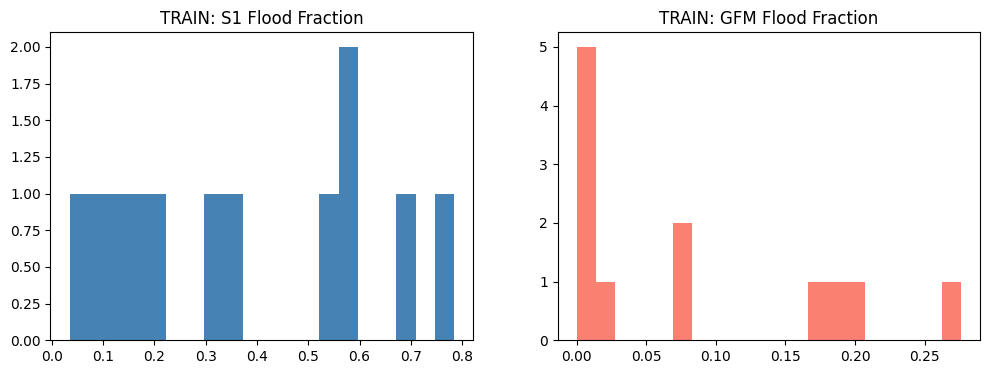

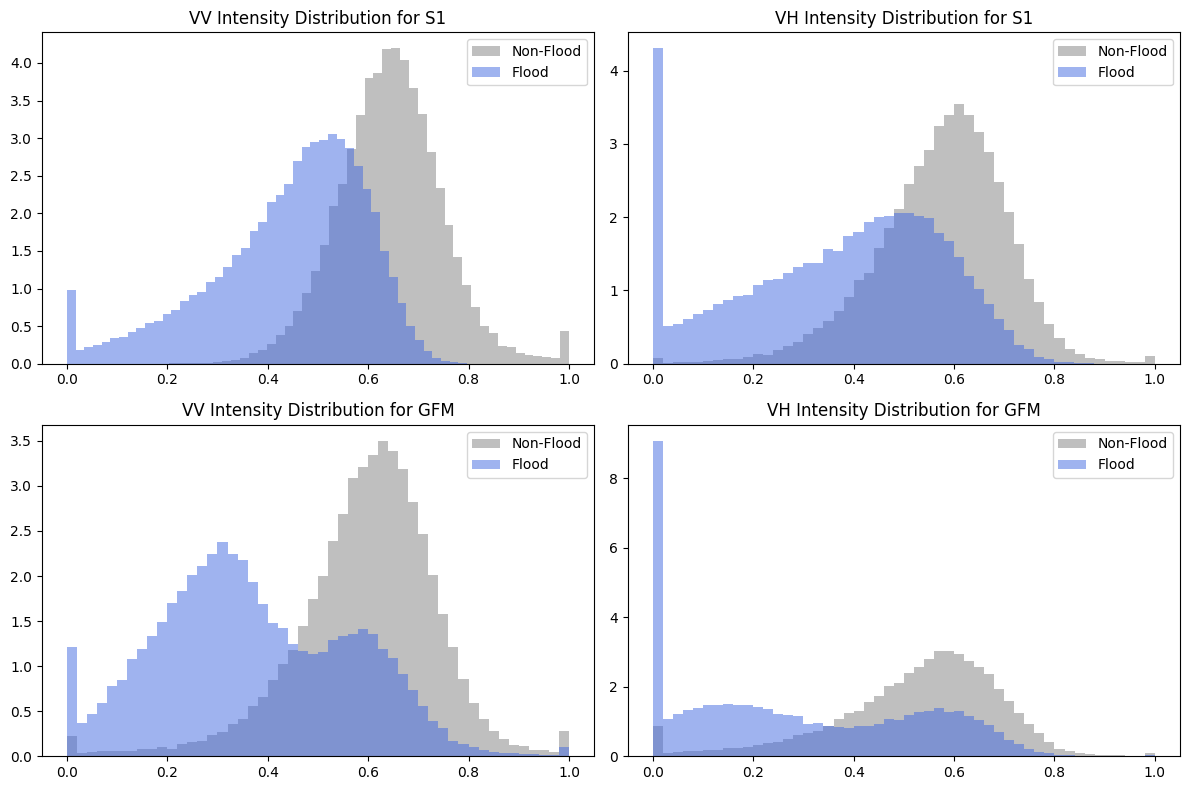

,sample_id,s1_flood_fraction,gfm_flood_fraction
0,selected_Gatineau_2019-04-01,0.783895,0.276392
1,selected_Gatineau_2019-04-08,0.206567,0.023557
2,selected_Gatineau_2019-04-13,0.703923,0.188051
3,selected_Gatineau_2019-04-25,0.345322,0.177301
4,selected_Gatineau_2019-04-26,0.527203,0.003080
5,selected_Gatineau_2019-05-02,0.104937,0.005825
6,selected_Ottawa_2019-04-01,0.592524,0.199216
7,selected_Ottawa_2019-04-08,0.118693,0.010430
8,selected_Ottawa_2019-04-13,0.577786,0.080751
9,selected_Ottawa_2019-04-25,0.153589,0.076642


In [ ]:
analyze_dataset_and_features(train_samples, "train")

## Define Eval Metrics

In [10]:
def plot_evaluation_metrics(y_true: np.ndarray, y_pred: np.ndarray, target: str):
    """Renders confusion matrix, precision-recall, and ROC curves for global arrays."""

    # Confusion Matrix (Calculated exactly once)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(3, 3))
    # Corrected labels: 0=Non-Flood, 1=Flood
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Flood", "Flood"], yticklabels=["Non-Flood", "Flood"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix ({target.upper()})")
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    plt.figure(figsize=(3, 3))
    plt.plot(recall, precision, label="Precision-Recall Curve", color="purple")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.title(f"PR Curve ({target.upper()})")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    plt.figure(figsize=(3, 3))
    plt.plot(fpr, tpr, label="ROC Curve", color="darkorange")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.title(f"ROC Curve ({target.upper()})")
    plt.show()

In [11]:
def evaluate_predictions(predictions_dict: dict, samples: list[dict], target: str = "s1_label") -> pd.DataFrame:
    """Evaluates predicted masks against ground truth and delegates global plotting."""
    results = []
    
    # Local states for fast numpy accumulation
    y_true_list = []
    y_pred_list = []

    for sample in samples:
        sample_id = sample.get("sample_id")
        if sample_id not in predictions_dict:
            continue

        # Load the true labels and valid mask from disk
        y_ref, valid_mask = load_target_masks(sample["npz_path"], target=target)
        
        # Apply the valid mask
        y_true = y_ref[valid_mask]
        y_pred = predictions_dict[sample_id][valid_mask].astype(bool)

        # Fast numpy logic for local metrics
        tp = (y_true & y_pred).sum()
        fp = (~y_true & y_pred).sum()
        fn = (y_true & ~y_pred).sum()
        
        eps = 1e-8
        precision = tp / (tp + fp + eps)
        recall = tp / (tp + fn + eps)
        f1 = 2 * precision * recall / (precision + recall + eps)

        results.append({
            "sample_id": sample_id,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })
        
        y_true_list.append(y_true)
        y_pred_list.append(y_pred)

    y_true_global = np.concatenate(y_true_list)
    y_pred_global = np.concatenate(y_pred_list)

    # Print and Plot
    print(f"\n--- Global Evaluation Report ({target.upper()}) ---")
    print(classification_report(y_true_global, y_pred_global, zero_division=0))
    plot_evaluation_metrics(y_true_global, y_pred_global, target)
    
    return pd.DataFrame(results)

## UNet

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import TensorDataset

from torch.utils.tensorboard import SummaryWriter
import datetime
from tqdm import tqdm
import torchvision

### Prepare Data (Patches and Batches)

Data generator creating 256x256 patches

In [14]:
def extract_smart_balanced_patches(samples: list[dict], target: str = "s1_label", patch_size: int = 256, patches_per_img: int = 50, return_coords: bool = False):
    """
    Targeted extraction using the 90% validity rule and centered jitter logic.
    Can optionally return the coordinates of the extracted patches for visualization.
    """
    X_spatial, X_weather, y_list, coords_list = [], [], [], []
    valid_key = "gfm_valid" if target == "gfm_mask" else "s1_label_valid"

    for sample in samples:
        with np.load(sample["npz_path"], allow_pickle=False) as data:
            s1 = data["s1"][:]
            env = data["env"][:]
            weather_vector = np.mean(data["weather"][:], axis=(1, 2)) 
            label = data[target][0] if data[target].ndim == 3 else data[target][:]
            valid = data[valid_key][0] if data[valid_key].ndim == 3 else data[valid_key][:]

        h, w = s1.shape[1:]
        if h < patch_size or w < patch_size:
            continue

        strict_valid_mask = (valid == 1)
        wet_mask = strict_valid_mask & (label == 1)
        dry_mask = strict_valid_mask & (label == 0)
        
        wet_coords = np.argwhere(wet_mask)
        dry_coords = np.argwhere(dry_mask)

        target_wet = patches_per_img // 2
        target_dry = patches_per_img - target_wet
        
        wet_found, dry_found = 0, 0
        attempts = 0
        max_attempts = patches_per_img * 100 

        if len(wet_coords) == 0:
            print(f"  -> {sample.get('sample_id')}: Skipped. 0 valid water pixels found.")
            continue

        while (wet_found < target_wet or dry_found < target_dry) and attempts < max_attempts:
            attempts += 1
            
            hunting_wet = wet_found < target_wet
            coords_to_sample = wet_coords if hunting_wet else dry_coords
            
            rand_idx = np.random.randint(0, len(coords_to_sample))
            center_y, center_x = coords_to_sample[rand_idx]
            
            jitter_y = np.random.randint(-32, 33)
            jitter_x = np.random.randint(-32, 33)
            
            y_s = center_y - (patch_size // 2) + jitter_y
            x_s = center_x - (patch_size // 2) + jitter_x
            
            if y_s < 0 or y_s + patch_size > h or x_s < 0 or x_s + patch_size > w:
                continue
                
            patch_validity = strict_valid_mask[y_s:y_s+patch_size, x_s:x_s+patch_size]
            if patch_validity.mean() < 0.90:
                continue 
                
            s1_patch = s1[:, y_s:y_s+patch_size, x_s:x_s+patch_size]
            env_patch = env[:, y_s:y_s+patch_size, x_s:x_s+patch_size]
            spatial_patch = np.concatenate([s1_patch, env_patch], axis=0)
            
            X_spatial.append(spatial_patch)
            X_weather.append(weather_vector) 
            y_list.append(label[y_s:y_s+patch_size, x_s:x_s+patch_size])
            
            coords_list.append({"y": y_s, "x": x_s, "is_wet": hunting_wet})
            
            if hunting_wet:
                wet_found += 1
            else:
                dry_found += 1
            
        print(f"  -> {sample.get('sample_id')}: Extracted {wet_found} Wet, {dry_found} Dry patches.")

    X_spatial_tensor = torch.tensor(np.stack(X_spatial), dtype=torch.float32)
    X_weather_tensor = torch.tensor(np.stack(X_weather), dtype=torch.float32)
    y_list_tensor = torch.tensor(np.stack(y_list), dtype=torch.float32).unsqueeze(1)

    if return_coords:
        return X_spatial_tensor, X_weather_tensor, y_list_tensor, coords_list
    
    return X_spatial_tensor, X_weather_tensor, y_list_tensor

### Define Model

In [15]:
class DoubleConv(nn.Module):
    """Executes the standard U-Net sequential block: (Conv2d -> BatchNorm2d -> ReLU) * 2"""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

In [16]:
class FiLM_UNet(nn.Module):
    """
    Multimodal U-Net that fuses 2D spatial data (SAR + Env) 
    with 1D global data (Weather) using Feature-wise Linear Modulation (FiLM).
    """
    def __init__(self, spatial_channels: int = 17, weather_channels: int = 6, out_channels: int = 1):
        super().__init__()

        # --- Standard Encoder ---
        # Input channels 17 (2 S1 + 15 Env)
        self.inc = DoubleConv(spatial_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
         
        # Bottleneck has 1024 channels
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))

        # --- FiLM Generator (Mini-MLP) ---
        # Takes the 6 weather variables and outputs 2048 parameters 
        # (1024 for gamma scales, 1024 for beta shifts)
        self.film_mlp = nn.Sequential(
            nn.Linear(weather_channels, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1024 * 2) 
        )

        # --- Standard Decoder ---
        self.up1_trans = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up1_conv = DoubleConv(1024, 512) 

        self.up2_trans = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up2_conv = DoubleConv(512, 256)

        self.up3_trans = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up3_conv = DoubleConv(256, 128)

        self.up4_trans = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up4_conv = DoubleConv(128, 64)

        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x_spatial: torch.Tensor, x_weather: torch.Tensor) -> torch.Tensor:
        # --- Encoder Path ---
        x1 = self.inc(x_spatial)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        bottleneck = self.down4(x4) # Shape: (Batch, 1024, 16, 16)
        
        # --- FiLM Modulation at the Bottleneck ---
        # 1. Pass weather through MLP
        film_params = self.film_mlp(x_weather) # Shape: (Batch, 2048)
        
        # 2. Split the output perfectly in half to get scales (gamma) and shifts (beta)
        gamma, beta = torch.chunk(film_params, chunks=2, dim=1) # Each is (Batch, 1024)
        
        # 3. Reshape so PyTorch knows how to broadcast them across the 16x16 spatial grid
        gamma = gamma.view(-1, 1024, 1, 1)
        beta = beta.view(-1, 1024, 1, 1)
        
        # 4. Apply the Affine Transformation: Y = (1 + gamma) * X + beta
        # (We use 1 + gamma to center the initial scaling at 1.0)
        bottleneck = (1 + gamma) * bottleneck + beta

        # --- Decoder Path ---
        up1 = self.up1_trans(bottleneck)
        cat1 = torch.cat([x4, up1], dim=1)
        dec1 = self.up1_conv(cat1)

        up2 = self.up2_trans(dec1)
        cat2 = torch.cat([x3, up2], dim=1)
        dec2 = self.up2_conv(cat2)

        up3 = self.up3_trans(dec2)
        cat3 = torch.cat([x2, up3], dim=1)
        dec3 = self.up3_conv(cat3)

        up4 = self.up4_trans(dec3)
        cat4 = torch.cat([x1, up4], dim=1)
        dec4 = self.up4_conv(cat4)

        logits = self.outc(dec4)
        return logits

In [ ]:
class BCEDiceLoss(nn.Module):
    """
    Combined BCE and Dice Loss for imbalanced image segmentation
    Expects raw logits from the model, NOT sigmoid probabilities
    """
    def __init__(self, smooth: float = 1e-5):
        super().__init__()
        self.smooth = smooth
        # BCEWithLogitsLoss combines Sigmoid + BCE for numerical stability
        self.bce = nn.BCEWithLogitsLoss()
        
    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # Calculate Standard BCE Loss
        bce_loss = self.bce(logits, targets)
        
        # Calculate Dice Loss a sigmoid to the raw logits to get probabilities (0 to 1)
        probs = torch.sigmoid(logits)
        
        # Flatten the spatial tensors so we can easily calculate intersection
        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)
        
        intersection = (probs_flat * targets_flat).sum()
        
        # Add smooth factor to prevent division by zero
        dice_score = (2. * intersection + self.smooth) / (probs_flat.sum() + targets_flat.sum() + self.smooth)
        dice_loss = 1.0 - dice_score
        
        # Return Combined Loss
        return bce_loss + dice_loss

### Train

In [18]:
def train_unet(model, train_loader, val_loader, epochs=10, device='cpu', run_name="film_unet_run_1"):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = BCEDiceLoss() 
    
    writer = SummaryWriter(log_dir=f"runs/{run_name}")
    print(f"TensorBoard initialized. Run `tensorboard --logdir runs` to view.")

    best_val_loss = float('inf')
    
    # Create a dictionary to track our losses
    history = {'train_loss': [], 'val_loss': []} 

    for epoch in range(epochs):
        print(f"\n--- Epoch {epoch+1}/{epochs} ---")
        
        # ==========================================
        # TRAINING PHASE
        # ==========================================
        model.train()
        train_loss = 0.0
        
        for spatial, weather, mask in tqdm(train_loader, desc="Training"):
            spatial, weather, mask = spatial.to(device), weather.to(device), mask.to(device)

            optimizer.zero_grad()
            logits = model(spatial, weather)
            loss = criterion(logits, mask)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # ==========================================
        # VALIDATION PHASE
        # ==========================================
        model.eval()
        val_loss = 0.0
        logged_images = False 
        
        with torch.no_grad():
            for spatial, weather, mask in tqdm(val_loader, desc="Validating"):
                spatial, weather, mask = spatial.to(device), weather.to(device), mask.to(device)

                logits = model(spatial, weather)
                loss = criterion(logits, mask)
                val_loss += loss.item()
                
                if not logged_images:
                    probs = torch.sigmoid(logits)
                    s1_vv = spatial[:, 0:1, :, :] 
                    img_grid = torch.cat([s1_vv, mask, probs], dim=3) 
                    grid = torchvision.utils.make_grid(img_grid, nrow=4, normalize=False)
                    writer.add_image('Val_Images/Radar_Target_Prediction', grid, epoch)
                    logged_images = True

        avg_val_loss = val_loss / len(val_loader)
        
        # Save the averages to our history dictionary
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        
        # ==========================================
        # METRICS & CHECKPOINTING
        # ==========================================
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        writer.add_scalar('Loss/Train', avg_train_loss, epoch)
        writer.add_scalar('Loss/Validation', avg_val_loss, epoch)
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "best_film_unet.pth")
            print(f"  -> Validation loss improved! Saved 'best_film_unet.pth'")

    writer.close()
    print("\nTraining Complete!")
    model.load_state_dict(torch.load("best_film_unet.pth"))
    
    return model, history

### Predict

In [19]:
import gc
from itertools import product

In [ ]:
def predict_single_image_in_patches(model: torch.nn.Module, spatial_numpy: np.ndarray, weather_numpy: np.ndarray, device: torch.device, patch_size: int = 256) -> np.ndarray:
    """Zero-overhead inference: Slices raw spatial data, pads edges, and injects global weather."""
    channels, orig_h, orig_w = spatial_numpy.shape
    
    # Pre-allocate the boolean prediction canvas
    pred_mask = np.zeros((orig_h, orig_w), dtype=bool)

    # Generate flat grid coordinates
    y_coords = range(0, orig_h, patch_size)
    x_coords = range(0, orig_w, patch_size)
    
    # Prepare the weather tensor once (since it's global for the whole image)
    # Add a batch dimension: Shape becomes (1, 6)
    x_weather = torch.from_numpy(weather_numpy).float().unsqueeze(0).to(device)

    with torch.no_grad():
        for y, x in product(y_coords, x_coords):
            # 4. Extract the tiny patch
            patch_np = spatial_numpy[:, y:y+patch_size, x:x+patch_size]
            curr_h, curr_w = patch_np.shape[1], patch_np.shape[2]
            
            # 5. Calculate padding ONLY for this specific chunk
            pad_h = (16 - (curr_h % 16)) % 16
            pad_w = (16 - (curr_w % 16)) % 16
            
            if pad_h > 0 or pad_w > 0:
                patch_np = np.pad(patch_np, ((0, 0), (0, pad_h), (0, pad_w)), mode='constant')
                
            # Predict using BOTH spatial and weather inputs
            x_spatial = torch.from_numpy(patch_np).float().unsqueeze(0).to(device)
            logits = model(x_spatial, x_weather)
            probs = torch.sigmoid(logits)
            
            # Convert to boolean and drop batch/channel dimensions
            preds = (probs > 0.5).cpu().numpy().squeeze()
            
            # Crop out any padding we added and slot into the canvas
            pred_mask[y:y+curr_h, x:x+curr_w] = preds[:curr_h, :curr_w]
            
            # Nuke spatial tensors immediately (keep x_weather for next loop)
            del patch_np, x_spatial, logits, probs, preds
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                
    # Clean up the global weather tensor after the grid is finished
    del x_weather

    return pred_mask

In [21]:
def predict_unet_masks(model: torch.nn.Module, samples: list[dict], device: torch.device, patch_size: int = 256) -> dict:
    """Orchestrates memory-safe multimodal patch inference."""
    model.to(device)
    model.eval()
    predictions = {}

    for sample in samples:
        sample_id = sample.get("sample_id")
        print(f"  -> Predicting grid patches for {sample_id}...")
        
        with np.load(sample["npz_path"], allow_pickle=False) as data:
            # Build the inputs exactly like the training extractor
            spatial_stack = np.concatenate([data["s1"][:], data["env"][:]], axis=0)
            weather_vector = np.mean(data["weather"][:], axis=(1, 2))
            
        # Delegate to zero-overhead multimodal chunker
        preds_original_size = predict_single_image_in_patches(model, spatial_stack, weather_vector, device, patch_size=patch_size)
        predictions[sample_id] = preds_original_size
        
        # Explicit RAM cleanup
        del spatial_stack, weather_vector
        gc.collect()

    return predictions

### Run

#### Prepare Data

In [22]:
# Build Training Data
print("Extracting training patches...")
X_spatial_tensor, X_weather_tensor, y_list_tensor = extract_smart_balanced_patches(train_samples, target="gfm_mask", patch_size=256, patches_per_img=100)
train_dataset = TensorDataset(X_spatial_tensor, X_weather_tensor, y_list_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

Extracting training patches...
  -> selected_Gatineau_2019-04-01: Extracted 50 Wet, 50 Dry patches.
  -> selected_Gatineau_2019-04-08: Extracted 50 Wet, 50 Dry patches.
  -> selected_Gatineau_2019-04-13: Extracted 50 Wet, 50 Dry patches.
  -> selected_Gatineau_2019-04-25: Extracted 50 Wet, 50 Dry patches.
  -> selected_Gatineau_2019-04-26: Extracted 50 Wet, 50 Dry patches.
  -> selected_Gatineau_2019-05-02: Extracted 50 Wet, 50 Dry patches.
  -> selected_Ottawa_2019-04-01: Extracted 50 Wet, 50 Dry patches.
  -> selected_Ottawa_2019-04-08: Extracted 50 Wet, 50 Dry patches.
  -> selected_Ottawa_2019-04-13: Extracted 50 Wet, 50 Dry patches.
  -> selected_Ottawa_2019-04-25: Extracted 50 Wet, 50 Dry patches.
  -> selected_Ottawa_2019-04-26: Extracted 50 Wet, 50 Dry patches.
  -> selected_Ottawa_2019-05-02: Extracted 50 Wet, 50 Dry patches.


In [23]:
# Build validation data
print("Extracting validation patches...")
X_s_v, X_w_v, y_l_v = extract_smart_balanced_patches(val_samples, target="gfm_mask", patch_size=256, patches_per_img=100)
val_dataset = TensorDataset(X_s_v, X_w_v, y_l_v)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=True)

Extracting validation patches...
  -> selected_Gatineau_2019-05-07: Extracted 50 Wet, 50 Dry patches.
  -> selected_Gatineau_2019-05-14: Extracted 50 Wet, 50 Dry patches.
  -> selected_Ottawa_2019-05-07: Extracted 50 Wet, 50 Dry patches.
  -> selected_Ottawa_2019-05-14: Extracted 50 Wet, 50 Dry patches.


In [24]:
# Build test data
print("Extracting test patches...")
X_s, X_w, y_l = extract_smart_balanced_patches(test_samples, target="gfm_mask", patch_size=256, patches_per_img=100)
test_dataset = TensorDataset(X_s, X_w, y_l)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

Extracting test patches...
  -> selected_Gatineau_2019-05-19: Extracted 50 Wet, 50 Dry patches.
  -> selected_Gatineau_2019-05-26: Extracted 50 Wet, 50 Dry patches.
  -> selected_Ottawa_2019-05-19: Extracted 50 Wet, 50 Dry patches.
  -> selected_Ottawa_2019-05-26: Extracted 50 Wet, 50 Dry patches.


##### Analyze

In [25]:
import matplotlib.patches as patches
from matplotlib.lines import Line2D

--- Analyzing Sample: selected_Gatineau_2019-05-14 ---
Total Grid Pixels: 15,823,028
Valid Pixels (Green): 5,452,658 (34.46% of total image)
Water Pixels in Valid Area: 38,745 (0.7106% of valid land)


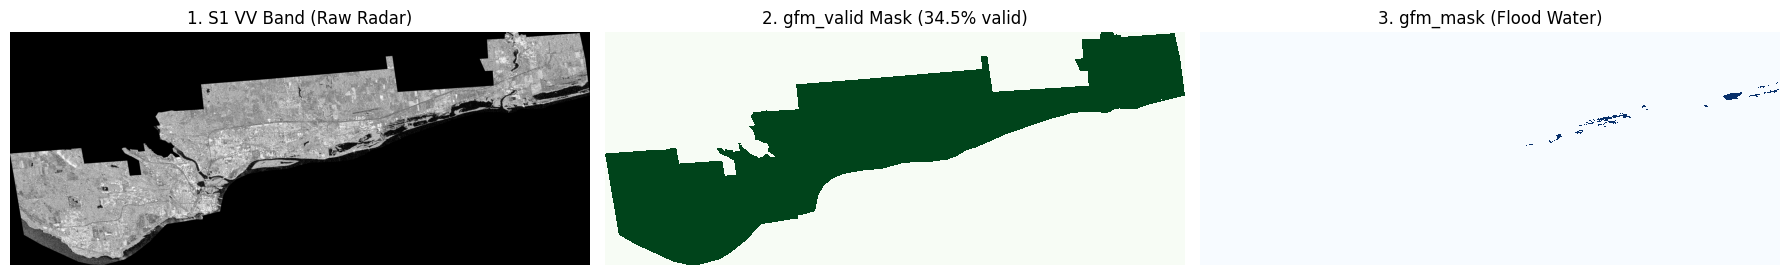

In [26]:
def analyze_valid_mask(sample: dict, target: str = "s1_label"):
    print(f"--- Analyzing Sample: {sample.get('sample_id')} ---")
    npz_path = sample["npz_path"]
    
    # Determine the correct valid key based on your target
    valid_key = "gfm_valid" if target == "gfm_mask" else "s1_label_valid"
    
    with np.load(npz_path, allow_pickle=False) as data:
        # Load the raw arrays
        vv = data["s1"][0]
        label = data[target][0] if data[target].ndim == 3 else data[target][:]
        valid = data[valid_key][0] if data[valid_key].ndim == 3 else data[valid_key][:]
        
    # Calculate absolute statistics
    total_pixels = valid.size
    valid_pixels = valid.sum()
    pct_valid = (valid_pixels / total_pixels) * 100
    
    water_in_valid = (label & valid).sum()
    pct_water_in_valid = (water_in_valid / valid_pixels) * 100 if valid_pixels > 0 else 0
    
    print(f"Total Grid Pixels: {total_pixels:,}")
    print(f"Valid Pixels (Green): {valid_pixels:,} ({pct_valid:.2f}% of total image)")
    print(f"Water Pixels in Valid Area: {water_in_valid:,} ({pct_water_in_valid:.4f}% of valid land)")
    
    # Visualize the arrays
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Background Radar
    axes[0].imshow(vv, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("1. S1 VV Band (Raw Radar)")
    axes[0].axis("off")
    
    # The Valid Mask
    axes[1].imshow(valid, cmap="Greens", interpolation="none")
    axes[1].set_title(f"2. {valid_key} Mask ({pct_valid:.1f}% valid)")
    axes[1].axis("off")
    
    # The Water Label
    axes[2].imshow(label, cmap="Blues", interpolation="none")
    axes[2].set_title(f"3. {target} (Flood Water)")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()

analyze_valid_mask(val_samples[1], target="gfm_mask")

In [ ]:
def investigate_the_void(sample: dict, target: str = "s1_label"):
    npz_path = sample["npz_path"]
    valid_key = "gfm_valid" if target == "gfm_mask" else "s1_label_valid"
    
    with np.load(npz_path, allow_pickle=False) as data:
        vv = data["s1"][0]  
        valid = data[valid_key][0] if data[valid_key].ndim == 3 else data[valid_key][:]
        
    # Isolate the exact coordinates of the "Void"
    # (Where the valid mask is False or 0)
    void_mask = (valid == 0) | (valid == False)
    
    print(f"--- Investigating the Void in {sample.get('sample_id')} ---")
    print(f"Valid Mask Void values: {np.unique(valid[void_mask])}")
    
    # Grab the S1 radar values exactly where the void is
    s1_in_void = vv[void_mask]
    
    # Check for NaNs
    nan_count = np.isnan(s1_in_void).sum()
    if nan_count > 0:
        print(f"S1 Void contains {nan_count:,} NaN values.")
        
    # Check the actual numbers (filtering out NaNs so min/max doesn't break)
    s1_numbers_in_void = s1_in_void[~np.isnan(s1_in_void)]
    
    if len(s1_numbers_in_void) > 0:
        print(f"S1 numeric MIN in Void: {np.nanmin(s1_numbers_in_void)}")
        print(f"S1 numeric MAX in Void: {np.nanmax(s1_numbers_in_void)}")
        
        # Print the most common values
        unique_vals, counts = np.unique(s1_numbers_in_void, return_counts=True)
        print("\nMost common numeric values in the S1 Void:")
        for val, count in zip(unique_vals[:5], counts[:5]):
            print(f"  Value: {val} occurs {count:,} times")
    else:
        print("S1 Void is entirely composed of NaNs.")

investigate_the_void(train_samples[0], target="s1_label")

--- Investigating the Void in selected_Gatineau_2019-04-01 ---
Valid Mask Void values: [0]
S1 numeric MIN in Void: 0.0
S1 numeric MAX in Void: 0.5758140683174133

Most common numeric values in the S1 Void:
  Value: 0.0 occurs 10,370,259 times
  Value: 0.05730995163321495 occurs 2 times
  Value: 0.10118560492992401 occurs 1 times
  Value: 0.10852455347776413 occurs 2 times
  Value: 0.12002212554216385 occurs 1 times


In [27]:
def visualize_actual_extracted_boxes(sample: dict, target: str = "gfm_mask", patch_size: int = 256, patches_per_img: int = 50):
    print("Running extractor to generate true patch coordinates...")
    
    _, _, _, coords = extract_smart_balanced_patches(
        samples=[sample], 
        target=target, 
        patch_size=patch_size, 
        patches_per_img=patches_per_img, 
        return_coords=True 
    )
    
    # Load the background image
    with np.load(sample["npz_path"], allow_pickle=False) as data:
        vv = data["s1"][0]  
        
    fig, ax = plt.subplots(1, 1, figsize=(16, 10))
    ax.imshow(vv, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"True Extracted Patches: {sample.get('sample_id')}", fontsize=16)
    
    wet_count, dry_count = 0, 0
    
    # Draw the exact boxes the extractor just made
    for box in coords:
        x_s = box["x"]
        y_s = box["y"]
        is_wet = box["is_wet"]
        
        edgecolor = 'dodgerblue' if is_wet else 'red'
        
        rect = patches.Rectangle(
            (x_s, y_s), patch_size, patch_size,
            linewidth=2.5, edgecolor=edgecolor, facecolor='none', alpha=0.9
        )
        ax.add_patch(rect)
        
        if is_wet: wet_count += 1
        else: dry_count += 1

    custom_lines = [
        Line2D([0], [0], color='dodgerblue', lw=3, label=f'True Extracted Flood ({wet_count})'),
        Line2D([0], [0], color='red', lw=3, label=f'True Extracted Dry ({dry_count})')
    ]
    ax.legend(handles=custom_lines, loc='upper right', fontsize=12)
    
    ax.axis("off")
    plt.tight_layout()
    plt.show()

Running extractor to generate true patch coordinates...
  -> selected_Gatineau_2019-05-14: Extracted 25 Wet, 25 Dry patches.


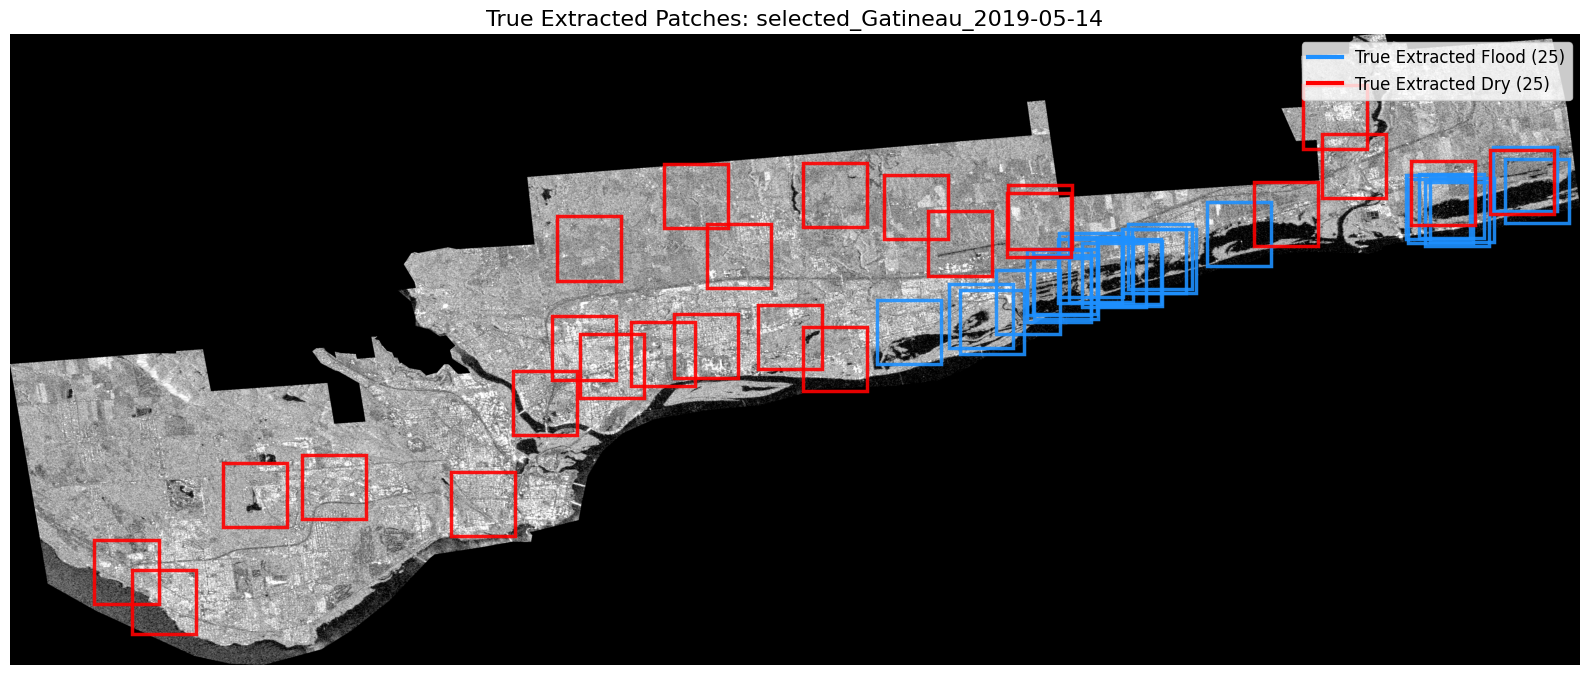

In [ ]:
visualize_actual_extracted_boxes(val_samples[1], target="gfm_mask", patch_size=256, patches_per_img=50)

#### Train

In [29]:
train_device = torch.device("cuda")

In [30]:
# Initialize and Train Model
print("Training U-Net...")
unet_model = FiLM_UNet(spatial_channels=17, weather_channels=6, out_channels=1)

unet_model, history = train_unet(
    model=unet_model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    epochs=20, 
    device=train_device
)

Training U-Net...
TensorBoard initialized. Run `tensorboard --logdir runs` to view.

--- Epoch 1/20 ---


Validating: 100%|██████████| 25/25 [00:07<00:00,  3.48it/s]


Train Loss: 1.0716 | Val Loss: 0.8884
  -> Validation loss improved! Saved 'best_film_unet.pth'

--- Epoch 2/20 ---


Validating: 100%|██████████| 25/25 [00:06<00:00,  3.95it/s]


Train Loss: 0.8417 | Val Loss: 0.8270
  -> Validation loss improved! Saved 'best_film_unet.pth'

--- Epoch 3/20 ---


...

Validating: 100%|██████████| 25/25 [00:06<00:00,  4.03it/s]


Train Loss: 0.6266 | Val Loss: 0.9269

--- Epoch 20/20 ---


Validating: 100%|██████████| 25/25 [00:05<00:00,  4.20it/s]

Train Loss: 0.6293 | Val Loss: 1.2692

Training Complete!



C:\Users\aquaf\AppData\Local\Temp\ipykernel_26144\3785162788.py:80: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_film_unet.pth"))


In [31]:
# Save Model
torch.save(unet_model.state_dict(), "film_unet_model_gfm_patched_bcediceloss.pth")
# torch.save(unet_model, "unet_model.pt")

# with open("unet_model.pkl", "wb") as f:
#     pickle.dump(unet_model, f)


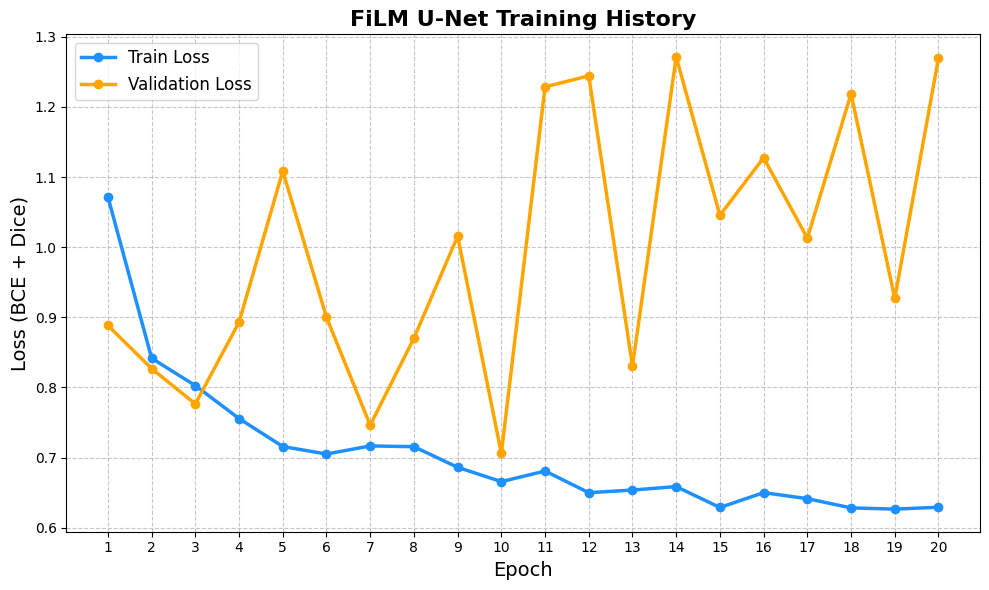

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Train Loss', color='dodgerblue', linewidth=2.5, marker='o')
plt.plot(history['val_loss'], label='Validation Loss', color='orange', linewidth=2.5, marker='o')

plt.title('FiLM U-Net Training History', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss (BCE + Dice)', fontsize=14)
# Make x-axis start at 1 instead of 0 for easier reading
plt.xticks(range(len(history['train_loss'])), range(1, len(history['train_loss']) + 1)) 

plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Predict

In [33]:
inference_device = torch.device("cpu")

In [34]:
# Explicitly resolve the absolute path
model_path = Path("film_unet_model_gfm_patched_bcediceloss.pth").resolve()

# Rebuild the model skeleton 
print("Initializing U-Net architecture...")
unet_model = FiLM_UNet(spatial_channels=17, weather_channels=6, out_channels=1)

# Load the weights (state_dict) from disk, FORCING them to the CPU
print(f"Loading saved weights from {model_path}...")
saved_weights = torch.load(
    str(model_path), 
    map_location=inference_device, 
    weights_only=True 
) 

# Inject the weights into the model skeleton
unet_model.load_state_dict(saved_weights)

# Also ensure the model skeleton itself is on the CPU
unet_model.to('cpu')
print("Model rehydrated successfully on CPU.")

Initializing U-Net architecture...
Loading saved weights from D:\Projects\FloodPredictionSandbox\notebooks\film_unet_model_gfm_patched_bcediceloss.pth...
Model rehydrated successfully on CPU.


In [35]:
# Generate Full-Image Predictions on Test Set
print("Generating patched U-Net predictions...")
# Using inference_device="cpu" (or "cuda" if you have >4GB VRAM)
unet_predictions = predict_unet_masks(unet_model, test_samples, inference_device, patch_size=256)

Generating patched U-Net predictions...
  -> Predicting grid patches for selected_Gatineau_2019-05-19...
  -> Predicting grid patches for selected_Gatineau_2019-05-26...
  -> Predicting grid patches for selected_Ottawa_2019-05-19...
  -> Predicting grid patches for selected_Ottawa_2019-05-26...


In [36]:
# save predictions  
with open("film_unet_predictions_gfm_patched_bcediceloss.pkl", "wb") as f:
    pickle.dump(unet_predictions, f)


Evaluating U-Net...

--- Global Evaluation Report (GFM_MASK) ---
              precision    recall  f1-score   support

       False       0.98      0.97      0.97  89000154
        True       0.47      0.55      0.51   4169861

    accuracy                           0.95  93170015
   macro avg       0.73      0.76      0.74  93170015
weighted avg       0.96      0.95      0.95  93170015



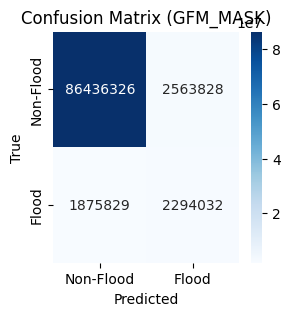

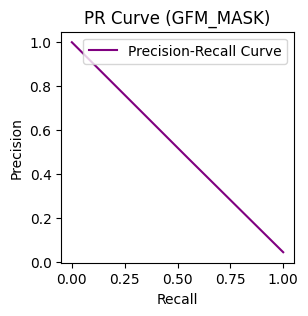

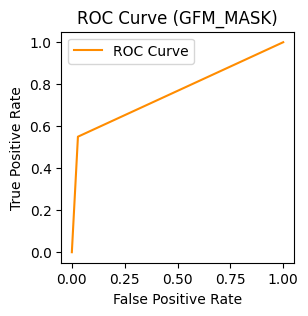

,sample_id,precision,recall,f1
0,selected_Gatineau_2019-05-19,0.877149,0.611457,0.720592
1,selected_Gatineau_2019-05-26,0.036997,0.804723,0.070741
2,selected_Ottawa_2019-05-19,0.856716,0.529278,0.654319
3,selected_Ottawa_2019-05-26,0.003178,0.771501,0.006331


In [37]:
# Evaluate against the ground truth S1 labels
print("Evaluating U-Net...")
df_eval_unet = evaluate_predictions(
    predictions_dict=unet_predictions, 
    samples=test_samples, 
    target="gfm_mask" 
)

display(df_eval_unet)

#### Debug

In [39]:
from sklearn.decomposition import PCA
import plotly.express as px

In [40]:
def extract_latent_features(model: FiLM_UNet, dataloader: DataLoader, device: torch.device, max_batches: int = 10) -> tuple[np.ndarray, np.ndarray]:
    """Extracts FiLM-modulated bottleneck features from the U-Net encoder for a subset of data."""
    model.to(device)
    model.eval()
    
    latent_vectors = []
    water_proportions = []

    with torch.no_grad():
        # Unpack all THREE items from the new multimodal dataloader
        for i, (X_spatial, X_weather, y_batch) in enumerate(dataloader):
            if i >= max_batches:
                break
                
            X_spatial = X_spatial.to(device)
            X_weather = X_weather.to(device)
            
            # Explicitly trace the spatial encoder path
            x1 = model.inc(X_spatial)
            x2 = model.down1(x1)
            x3 = model.down2(x2)
            x4 = model.down3(x3)
            raw_bottleneck = model.down4(x4) 
            
            # Apply the FiLM Modulation! 
            # (Without this, the latent space would completely ignore the weather data)
            film_params = model.film_mlp(X_weather)
            gamma, beta = torch.chunk(film_params, chunks=2, dim=1)
            
            gamma = gamma.view(-1, 1024, 1, 1)
            beta = beta.view(-1, 1024, 1, 1)
            
            # This is the true, fused multimodal latent space
            modulated_bottleneck = (1 + gamma) * raw_bottleneck + beta
            
            # Flatten the modulated bottleneck spatial/channel dimensions
            batch_size = modulated_bottleneck.size(0)
            flat_bottleneck = modulated_bottleneck.view(batch_size, -1).cpu().numpy()
            
            # Calculate proportion of water in the true label for coloring our plot
            water_prop = y_batch.view(batch_size, -1).mean(dim=1).cpu().numpy()
            
            latent_vectors.append(flat_bottleneck)
            water_proportions.append(water_prop)
            
    # Postconditions
    assert len(latent_vectors) > 0, "Failed to extract any latent vectors."
    
    X_latent = np.concatenate(latent_vectors, axis=0)
    y_prop = np.concatenate(water_proportions, axis=0)
    
    return X_latent, y_prop

In [41]:
def plot_latent_space(X_latent: np.ndarray, y_prop: np.ndarray):
    """Reduces the bottleneck latent space using PCA and plots the distribution."""
    
    # Compress the high-dimensional bottleneck down to 2 Principal Components
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_latent)
    
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_prop, cmap='coolwarm', alpha=0.8, edgecolors='k')
    cbar = plt.colorbar(scatter)
    cbar.set_label('Flood Proportion in Patch')
    
    plt.title("PCA of U-Net Latent Space (Bottleneck)")
    plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)")
    plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

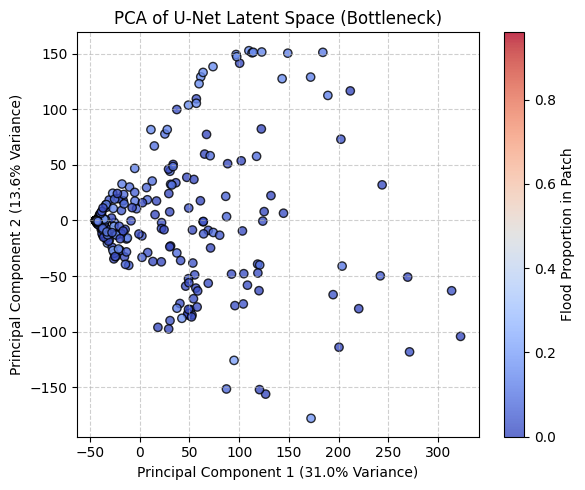

In [42]:
X_latent, y_prop = extract_latent_features(unet_model, test_loader, inference_device, max_batches=50)
plot_latent_space(X_latent, y_prop)

In [43]:

def plot_latent_space_3d(X_latent: np.ndarray, y_prop: np.ndarray):
    """
    Reduces the bottleneck latent space using PCA and plots an interactive 
    3D distribution to visualize class separation.
    """
    print("Compressing latent space to 3 dimensions...")
    
    # Compress down to 3 Principal Components
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_latent)
    
    # Package into a DataFrame for Plotly
    # We include the variance percentages directly in the column names
    col_x = f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
    col_y = f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
    col_z = f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)"
    
    df = pd.DataFrame({
        col_x: X_pca[:, 0],
        col_y: X_pca[:, 1],
        col_z: X_pca[:, 2],
        "Flood Proportion": y_prop
    })
    
    # Create the 3D Interactive Scatter Plot
    fig = px.scatter_3d(
        df, 
        x=col_x, 
        y=col_y, 
        z=col_z,
        color="Flood Proportion",
        color_continuous_scale="RdBu_r", # The Plotly equivalent of 'coolwarm'
        opacity=0.8,
        title="3D PCA of U-Net Latent Space (Bottleneck)"
    )
    
    # Styling: Make markers legible with a subtle border
    fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))
    
    # Tighten the layout so the 3D cube uses maximum screen space
    fig.update_layout(
        margin=dict(l=0, r=0, b=0, t=50),
        scene=dict(
            xaxis_title=col_x,
            yaxis_title=col_y,
            zaxis_title=col_z
        )
    )
    
    fig.show()

plot_latent_space_3d(X_latent, y_prop)

Compressing latent space to 3 dimensions...


#### Print Model

In [42]:
from torchviz import make_dot
from torchinfo import summary

In [ ]:
def inspect_model_shapes(model, device):
    """Prints a detailed summary of tensor shapes and parameter counts."""
    print("--- FiLM U-Net Mathematical Blueprint ---")
    
    # Create dummy tensors that match your exact DataLoader batch size and channels
    # Batch Size: 16 | Spatial: 17 channels, 256x256 | Weather: 6 variables
    dummy_spatial = torch.randn(16, 17, 256, 256).to(device)
    dummy_weather = torch.randn(16, 6).to(device)
    
    # Run the summary
    model_summary = summary(
        model, 
        input_data=(dummy_spatial, dummy_weather),
        col_names=["input_size", "output_size", "num_params"],
        depth=4 # How deep into the nested Sequential blocks
    )
    print(model_summary)

inspect_model_shapes(unet_model, inference_device)

--- FiLM U-Net Mathematical Blueprint ---
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
FiLM_UNet                                [16, 17, 256, 256]        [16, 1, 256, 256]         --
├─DoubleConv: 1-1                        [16, 17, 256, 256]        [16, 64, 256, 256]        --
│    └─Sequential: 2-1                   [16, 17, 256, 256]        [16, 64, 256, 256]        --
│    │    └─Conv2d: 3-1                  [16, 17, 256, 256]        [16, 64, 256, 256]        9,792
│    │    └─BatchNorm2d: 3-2             [16, 64, 256, 256]        [16, 64, 256, 256]        128
│    │    └─ReLU: 3-3                    [16, 64, 256, 256]        [16, 64, 256, 256]        --
│    │    └─Conv2d: 3-4                  [16, 64, 256, 256]        [16, 64, 256, 256]        36,864
│    │    └─BatchNorm2d: 3-5             [16, 64, 256, 256]        [16, 64, 256, 256]        128
│    │    └─ReLU: 3-6                    [16, 64, 256, 256]        [16, 64, 256,

In [ ]:
def draw_model_architecture(model, device):
    """Generates a PDF flowchart of the model's forward pass."""
    dummy_spatial = torch.randn(1, 17, 256, 256).to(device)
    dummy_weather = torch.randn(1, 6).to(device)
    
    # Run a forward pass to build the graph
    model.eval()
    logits = model(dummy_spatial, dummy_weather)
    
    # Create the graph
    dot = make_dot(logits, params=dict(model.named_parameters()))
    
    dot.format = 'pdf'
    dot.render("FiLM_UNet_Architecture")
    print("Saved 'FiLM_UNet_Architecture.pdf' to your local directory!")

draw_model_architecture(unet_model, inference_device)

Saved 'FiLM_UNet_Architecture.pdf' to your local directory!
